# Customer Lifetime Value Prediction using Probabilistic Modeling

**Author:** Kumaresan K  
**Objective:** Predict future customer value and segment customers for targeted marketing using probabilistic CLV modeling (BG/NBD + Gamma-Gamma).

---


## 1. Introduction

Understanding customer lifetime value (CLV) is critical for businesses seeking to optimize marketing investment and customer retention strategies. Not all customers contribute equally to revenue, and identifying high-value customers enables targeted engagement and efficient resource allocation.

This project applies probabilistic customer lifetime value modeling to transactional e-commerce data to estimate future purchasing behavior and monetary contribution at the individual customer level. Using the BG/NBD model for purchase frequency and the Gamma-Gamma model for monetary value, we estimate expected future revenue and segment customers into value tiers.

The analysis aims to:

- Model repeat purchasing behavior and customer survival probability  
- Estimate future customer lifetime value (CLV)  
- Identify high-value customer segments  
- Derive actionable marketing strategies based on predicted value  

This approach transforms raw transaction data into forward-looking customer intelligence for strategic decision-making.


In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from lifetimes import BetaGeoFitter
from lifetimes.plotting import plot_frequency_recency_matrix
from lifetimes import GammaGammaFitter

## 2. Data Preparation

The dataset consists of transactional records from an online retail business, including purchase dates, quantities, prices, and customer identifiers. Preprocessing steps ensure that the data accurately represents valid customer purchasing behavior.

Key preparation steps include:

- Removing transactions without valid customer identifiers  
- Excluding returns and negative quantities  
- Computing transaction-level revenue  
- Converting timestamps to datetime format  

These steps ensure reliable customer-level aggregation for lifetime valu modeling.


In [31]:
data = pd.read_csv("../data/raw/data.csv", encoding="ISO-8859-1")

In [32]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [34]:
data.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

remove the rows with no customerID

In [35]:
data = data.dropna(subset=["CustomerID"])
data["CustomerID"] = data["CustomerID"].astype(int)

In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  int32  
 7   Country      406829 non-null  object 
dtypes: float64(1), int32(1), int64(1), object(5)
memory usage: 26.4+ MB


In [37]:
data['CustomerID'].isna().sum()

0

In [38]:
data.shape

(406829, 8)

In [39]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom


In [40]:
data[data["Quantity"]<0]["Quantity"].count()

8905

Remove the Quantity less than zero

In [41]:
data = data[data["Quantity"] > 0]

In [42]:
data[data["UnitPrice"]<0]["UnitPrice"].count()

0

In [43]:
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])

In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  object        
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  int32         
 7   Country      397924 non-null  object        
dtypes: datetime64[ns](1), float64(1), int32(1), int64(1), object(4)
memory usage: 25.8+ MB


Create revenue column 

In [45]:
data["Revenue"] = data["Quantity"] * data["UnitPrice"]

In [46]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 3. Cohort Analysis

Cohort analysis evaluates customer retention by grouping customers based on their acquisition month and tracking repeat purchasing behavior over time. This analysis provides insight into customer engagement dynamics and validates the suitability of probabilistic lifetime modeling.

Retention patterns reveal a sharp decline after the first purchase, followed by stabilization among a smaller loyal customer base. The presence of repeat purchasing behavior and heterogeneous retention across cohorts supports the application of BG/NBD modeling assumptions.


In [47]:
data["CohortMonth"] = data.groupby("CustomerID")["InvoiceDate"].transform('min').dt.to_period('M')
data["InvoiceMonth"] = data["InvoiceDate"].dt.to_period('M')

In [48]:
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,CohortMonth,InvoiceMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12
...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20,2011-08,2011-12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,2011-08,2011-12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011-08,2011-12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011-08,2011-12


In [49]:
cohort_index = (data['InvoiceMonth'] - data['CohortMonth']).apply(lambda x: x.n)

data['CohortIndex'] = cohort_index

In [50]:
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,CohortMonth,InvoiceMonth,CohortIndex
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,2010-12,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,2010-12,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12,0
...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20,2011-08,2011-12,4
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,2011-08,2011-12,4
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011-08,2011-12,4
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011-08,2011-12,4


In [51]:
cohort_data = data.groupby(['CohortMonth','CohortIndex'])['CustomerID'].nunique().reset_index()

In [52]:
cohort_data

,CohortMonth,CohortIndex,CustomerID
0,2010-12,0,885
1,2010-12,1,324
2,2010-12,2,286
3,2010-12,3,340
4,2010-12,4,321
...,...,...,...
86,2011-10,1,86
87,2011-10,2,41
88,2011-11,0,324
89,2011-11,1,36


In [53]:
cohort_table = cohort_data.pivot(index='CohortMonth',
                                 columns='CohortIndex',
                                 values='CustomerID')
cohort_table

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
cohort_size = cohort_table.iloc[:,0]

retention = cohort_table.divide(cohort_size, axis=0)

retention

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN
2011-05,1.0,0.190141,0.172535,0.172535,0.207746,0.232394,0.264085,0.095070,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.173554,0.157025,0.264463,0.231405,0.334711,0.095041,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.180851,0.207447,0.223404,0.271277,0.111702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.207101,0.248521,0.242604,0.124260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


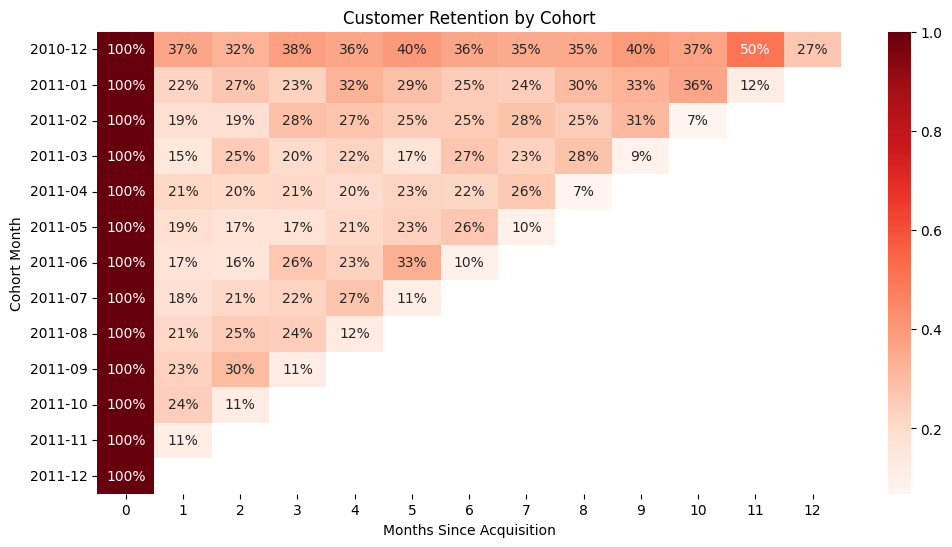

In [93]:
plt.figure(figsize=(12,6))
sns.heatmap(retention,
           annot=True,
            fmt=".0%",
           cmap='Reds')

plt.title("Customer Retention by Cohort")
plt.xlabel("Months Since Acquisition")
plt.ylabel("Cohort Month")
os.makedirs("../images", exist_ok=True)
plt.savefig("../images/cohortImage.png", dpi=300, bbox_inches="tight")
plt.show()

Cohort retention analysis reveals a sharp decline after the first purchase, with only (15–30%) of customers returning in the subsequent month, indicating a high proportion of one-time buyers. However, customers who remain active beyond the first 2–3 months exhibit stable long-term retention (20–30%), suggesting the presence of a loyal customer segment. Earlier acquisition cohorts demonstrate higher initial retention compared to later cohorts, indicating stronger historical customer quality. The observed retention decay and repeat purchasing behavior support the suitability of probabilistic CLV modeling.

## 4. RFM Feature Engineering

Customer purchasing behavior is summarized using Recency, Frequency, and Monetary (RFM) metrics:

- **Recency:** time between first and most recent purchase  
- **Frequency:** number of repeat purchases  
- **Monetary:** average revenue per transaction  

These features capture customer engagement intensity and spending level, forming the core inputs for probabilistic CLV modeling. The resulting distributions exhibit strong right skew and heavy tails, indicating substantial heterogeneity in custome value.


In [56]:
snapshot_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)

In [57]:
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [58]:
rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'Revenue': 'sum'                                          # Monetary
})

rfm.columns = ['recency','frequency','monetary']


In [59]:
customer_age = data.groupby("CustomerID")["InvoiceDate"].agg(lambda x:(snapshot_date - x.min()).days)

rfm["T"] = customer_age

In [60]:
rfm

,recency,frequency,monetary,T
CustomerID,,,,
12346,326,1,77183.60,326
12347,2,7,4310.00,367
12348,75,4,1797.24,358
12349,19,1,1757.55,19
12350,310,1,334.40,310
...,...,...,...,...
18280,278,1,180.60,278
18281,181,1,80.82,181
18282,8,2,178.05,126


In [61]:
rfm["frequency"] = rfm["frequency"] - 1

In [62]:
rfm = rfm[rfm["frequency"]>0]

<Axes: xlabel='frequency', ylabel='Count'>

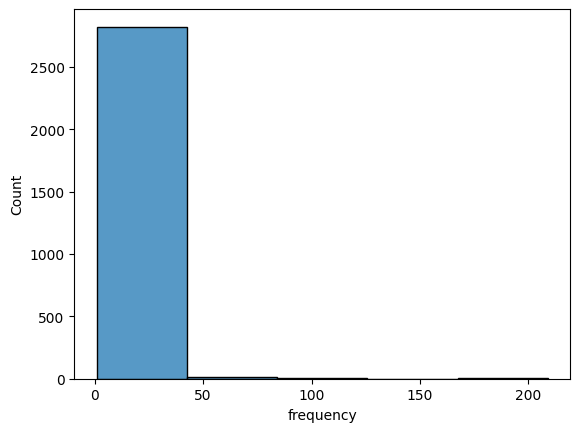

In [63]:
sns.histplot(rfm["frequency"], bins=5)

<Axes: xlabel='recency', ylabel='Count'>

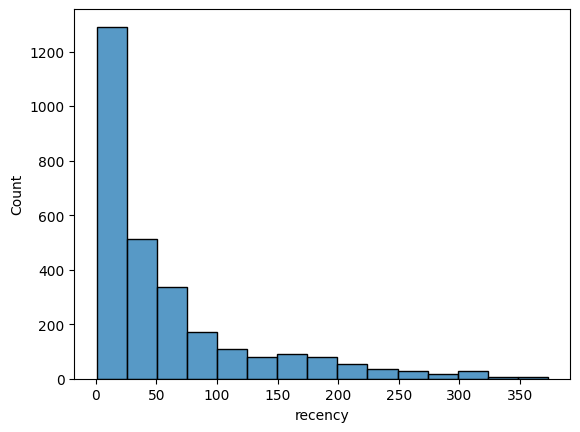

In [64]:
sns.histplot(rfm["recency"], bins=15)

<Axes: xlabel='monetary', ylabel='Count'>

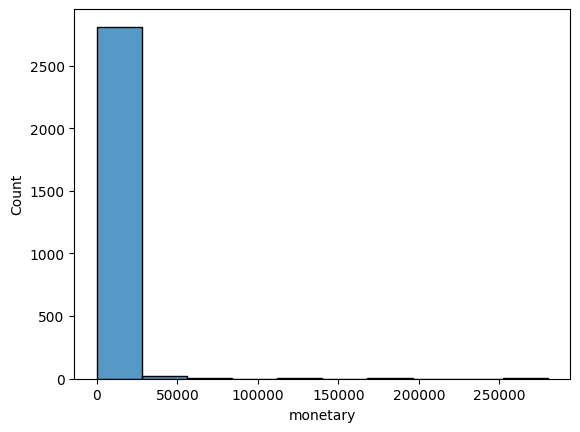

In [65]:
sns.histplot(rfm["monetary"], bins=10)

RFM distributions exhibit strong right skew with heavy tails, indicating substantial heterogeneity in customer purchasing behavior. Frequency distribution shows a large proportion of low-repeat customers alongside a small group of highly frequent buyers. Recency distribution reflects a mixture of active and inactive customers, while monetary distribution reveals a small segment of high-spending customers contributing disproportionate revenue. These patterns align with typical e-commerce behavior and support the suitability of probabilistic CLV modeling.

## 5. BG/NBD Purchase Modeling

The BG/NBD (Beta-Geometric / Negative Binomial Distribution) model estimates future purchase frequency and customer survival probability based on observed recency and frequency patterns.

Customers with recent and frequent purchases exhibit high predicted future transactions and survival likelihood, while those with long inactivity periods show near-zero purchase probability. This modeling distinguishes active customers from churned customers and provides forward-looking purchase estimates for CLV calculaton.


In [66]:
bgf = BetaGeoFitter(penalizer_coef=0.001)

bgf.fit(rfm["frequency"], rfm["recency"], rfm["T"])

<lifetimes.BetaGeoFitter: fitted with 2845 subjects, a: 1.67, alpha: 0.28, b: 4.96, r: 0.28>

In [67]:
bgf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
r,0.281046,0.006169,0.268956,0.293137
alpha,0.283648,0.012909,0.258346,0.308949
a,1.672693,0.066238,1.542865,1.802520
b,4.962450,0.231089,4.509517,5.415384


In [68]:
rfm["future_purchase_6m"] = bgf.predict(
    180,
    rfm["frequency"],
    rfm["recency"],
    rfm["T"]
)

In [69]:
rfm[rfm["future_purchase_6m"]>1]

,recency,frequency,monetary,T,future_purchase_6m
CustomerID,,,,,
12371,45,1,1887.96,60,1.567198
12452,17,1,430.57,17,3.368962
12504,18,1,482.05,30,2.113686
12508,26,1,398.27,29,2.547571
12512,66,1,138.03,66,1.637320
...,...,...,...,...,...
18123,24,1,589.44,31,2.329408
18139,18,5,8438.34,18,9.122922
18205,36,1,517.36,75,1.081018


C:\Users\kumar\anaconda3\Lib\site-packages\lifetimes\fitters\beta_geo_fitter.py:256: RuntimeWarning: overflow encountered in double_scalars
  denominator = 1 + (x > 0) * (a / (b + x - 1)) * ((alpha + T) / (alpha + recency)) ** (r + x)


<Axes: title={'center': 'Expected Number of Future Purchases for 1 Unit of Time,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

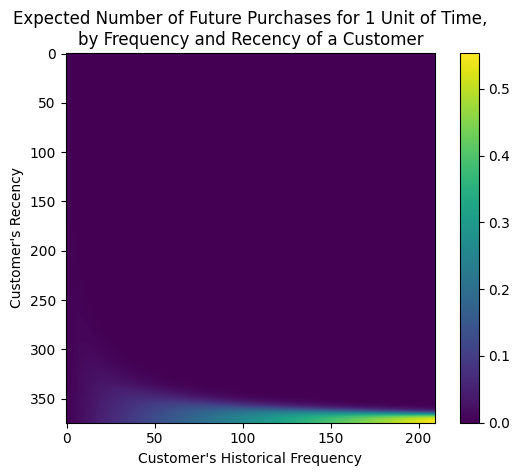

In [70]:
from lifetimes.plotting import plot_frequency_recency_matrix

plot_frequency_recency_matrix(bgf)

In [71]:
rfm['prob_alive'] = bgf.conditional_probability_alive(
    rfm['frequency'],
    rfm['recency'],
    rfm['T']
)

In [72]:
rfm

,recency,frequency,monetary,T,future_purchase_6m,prob_alive
CustomerID,,,,,,
12347,2,6,4310.00,367,2.064611e-13,8.253194e-14
12348,75,3,1797.24,358,3.391755e-02,2.430331e-02
12352,36,7,2506.04,297,4.968285e-06,1.464015e-06
12356,23,2,2811.43,326,9.224366e-03,8.569394e-03
12358,2,1,1168.06,151,1.625507e-02,1.359382e-02
...,...,...,...,...,...,...
18272,3,5,3078.58,247,1.916380e-09,6.566554e-10
18273,2,2,204.00,258,9.677957e-05,7.377702e-05
18282,8,1,178.05,126,1.143419e-01,8.298817e-02


<Axes: xlabel='prob_alive', ylabel='Count'>

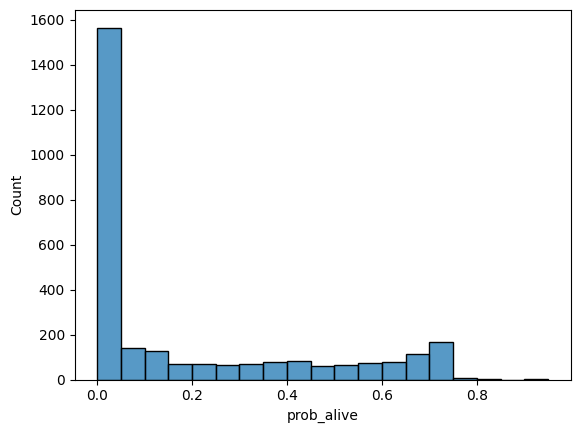

In [73]:
sns.histplot(rfm["prob_alive"])

BG/NBD results indicate that a substantial proportion of customers exhibit near-zero survival probability, reflecting long inactivity periods relative to their observed lifetime. Customers with high repeat frequency and recent purchasing behavior show higher expected future transaction counts and survival likelihood. The model effectively distinguishes active versus churned customers based on recency–frequency dynamics, consistent with observed e-commerce retention patterns.

## 6. Gamma-Gamma Monetary Modeling and CLV Estimation

The Gamma-Gamma model estimates expected monetary value per future transaction, assuming independence between purchase frequency and spending behavior. Combined with BG/NBD purchase predictions, this enables estimation of customer lifetime value (CLV) over a specified time horizon.

CLV estimates reveal strong heterogeneity, with a small segment of customers generating disproportionately high projected future revenue. Although moderate correlation between frequency and monetary value is observed, the model remains suitable for relative value segmentation and marketing prioritizaton.


In [74]:
rfm[['frequency','monetary']].corr()

,frequency,monetary
frequency,1.000000,0.549287
monetary,0.549287,1.000000


Gamma-Gamma modeling assumes independence between purchase frequency and monetary value. The observed correlation (0.55) indicates moderate positive association, suggesting that frequent buyers also tend to spend more. While this partially violates model assumptions, such dependence is common in retail data. The Gamma-Gamma model is therefore applied with caution, and CLV estimates should be interpreted as approximate relative value indicators rather than exact monetary forecasts.

In [75]:
ggf = GammaGammaFitter(penalizer_coef=0.001)

ggf.fit(
    rfm["frequency"],
    rfm["monetary"]
)

<lifetimes.GammaGammaFitter: fitted with 2845 subjects, p: 11.69, q: 0.45, v: 11.56>

In [76]:
rfm["expected_value"] = ggf.conditional_expected_average_profit(
    rfm["frequency"],
    rfm["monetary"]
)

In [77]:
rfm

,recency,frequency,monetary,T,future_purchase_6m,prob_alive,expected_value
CustomerID,,,,,,,
12347,2,6,4310.00,367,2.064611e-13,8.253194e-14,4346.177630
12348,75,3,1797.24,358,3.391755e-02,2.430331e-02,1829.935066
12352,36,7,2506.04,297,4.968285e-06,1.464015e-06,2524.745618
12356,23,2,2811.43,326,9.224366e-03,8.569394e-03,2885.427080
12358,2,1,1168.06,151,1.625507e-02,1.359382e-02,1238.163258
...,...,...,...,...,...,...,...
18272,3,5,3078.58,247,1.916380e-09,6.566554e-10,3110.305508
18273,2,2,204.00,258,9.677957e-05,7.377702e-05,214.858127
18282,8,1,178.05,126,1.143419e-01,8.298817e-02,199.017217


In [78]:
rfm["CLV_6m"] = ggf.customer_lifetime_value(
    bgf,
    rfm["frequency"],
    rfm["recency"],
    rfm["T"],
    rfm["monetary"],
    time=6,
    discount_rate=0.01,
    freq='D'
)

In [79]:
rfm

,recency,frequency,monetary,T,future_purchase_6m,prob_alive,expected_value,CLV_6m
CustomerID,,,,,,,,
12347,2,6,4310.00,367,2.064611e-13,8.253194e-14,4346.177630,8.684463e-10
12348,75,3,1797.24,358,3.391755e-02,2.430331e-02,1829.935066,6.004631e+01
12352,36,7,2506.04,297,4.968285e-06,1.464015e-06,2524.745618,1.214627e-02
12356,23,2,2811.43,326,9.224366e-03,8.569394e-03,2885.427080,2.574710e+01
12358,2,1,1168.06,151,1.625507e-02,1.359382e-02,1238.163258,1.948427e+01
...,...,...,...,...,...,...,...,...
18272,3,5,3078.58,247,1.916380e-09,6.566554e-10,3110.305508,5.772400e-06
18273,2,2,204.00,258,9.677957e-05,7.377702e-05,214.858127,2.012158e-02
18282,8,1,178.05,126,1.143419e-01,8.298817e-02,199.017217,2.203758e+01


<Axes: xlabel='CLV_6m', ylabel='Count'>

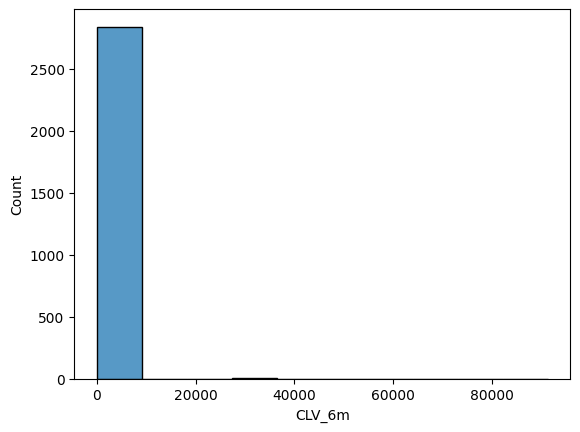

In [80]:
sns.histplot(rfm["CLV_6m"], bins=10)

## 7. CLV Segmentation

Customers are segmented into quartile-based value tiers (Low, Mid, High, VIP) according to predicted CLV. This segmentation produces balanced group sizes while revealing substantial differences in expected future value.

Analysis shows that recency is the dominant driver of CLV: customers with recent purchasing activity exhibit significantly higher predicted value even when historical purchase frequency is lower. Conversely, historically frequent customers with long inactivity display near-zero CLV, highlighting the distinction between past and future customer vaue.


In [81]:
rfm["labels"] = pd.qcut(
    rfm["CLV_6m"],
    4,
    labels=["Low", "Mid", "High", "VIP"]
)

In [82]:
rfm

,recency,frequency,monetary,T,future_purchase_6m,prob_alive,expected_value,CLV_6m,labels
CustomerID,,,,,,,,,
12347,2,6,4310.00,367,2.064611e-13,8.253194e-14,4346.177630,8.684463e-10,Low
12348,75,3,1797.24,358,3.391755e-02,2.430331e-02,1829.935066,6.004631e+01,High
12352,36,7,2506.04,297,4.968285e-06,1.464015e-06,2524.745618,1.214627e-02,Mid
12356,23,2,2811.43,326,9.224366e-03,8.569394e-03,2885.427080,2.574710e+01,Mid
12358,2,1,1168.06,151,1.625507e-02,1.359382e-02,1238.163258,1.948427e+01,Mid
...,...,...,...,...,...,...,...,...,...
18272,3,5,3078.58,247,1.916380e-09,6.566554e-10,3110.305508,5.772400e-06,Low
18273,2,2,204.00,258,9.677957e-05,7.377702e-05,214.858127,2.012158e-02,Mid
18282,8,1,178.05,126,1.143419e-01,8.298817e-02,199.017217,2.203758e+01,Mid


In [83]:
rfm["labels"].value_counts()

labels
Low     712
Mid     711
High    711
VIP     711
Name: count, dtype: int64

Customers were segmented into four value tiers (Low, Mid, High, VIP) based on predicted 6-month customer lifetime value (CLV) using quartile thresholds. Each segment contains approximately equal numbers of customers, ensuring balanced comparison across value groups. Despite similar segment sizes, CLV distribution is highly skewed, with VIP customers contributing disproportionately higher projected revenue compared to lower tiers. This segmentation highlights substantial heterogeneity in customer value and enables targeted marketing strategies based on expected future profitability.

In [84]:
rfm.groupby('labels')['CLV_6m'].sum()

labels
Low          0.304107
Mid       4330.077950
High     84547.444729
VIP     955509.907689
Name: CLV_6m, dtype: float64

Quartile-based CLV segmentation produces evenly sized customer groups but reveals substantial differences in projected future value, confirming strong heterogeneity in customer profitability. This segmentation provides a practical framework for value-based targeting and resource allocation.

## 8. Marketing Strategy Implications

CLV segmentation enables value-based marketing strategies aligned with predicted profitability:

- **VIP:** prioritize retention through loyalty rewards and personalized engagement  
- **High:** target upsell and cross-sell opportunities to elevate value  
- **Mid:** nurture engagement through tailored promotions  
- **Low:** apply cost-efficient reactivation campaigns  

Revenue concentration analysis confirms that a minority of customers contributes a majority of predicted future revenue, supporting focused investment in high-value segments to maximize marketing return.


In [85]:
segment_profile = rfm.groupby('labels').agg({
    'frequency':'mean',
    'recency':'mean',
    'monetary':'mean',
    'CLV_6m':'mean'
})

segment_profile

,frequency,recency,monetary,CLV_6m
labels,,,,
Low,12.790730,11.783708,7513.441924,0.000427
Mid,3.596343,28.779184,1665.020113,6.090124
High,1.825598,88.136428,895.794307,118.913424
VIP,1.736990,106.862166,1581.978159,1343.895791


CLV segmentation indicates that customers with the most recent purchasing activity exhibit the highest predicted lifetime value, even when historical purchase frequency is lower. Conversely, customers with high past purchase counts but long inactivity show near-zero future value, demonstrating that recency is the dominant driver of probabilistic CLV.

**CLV Distribution**

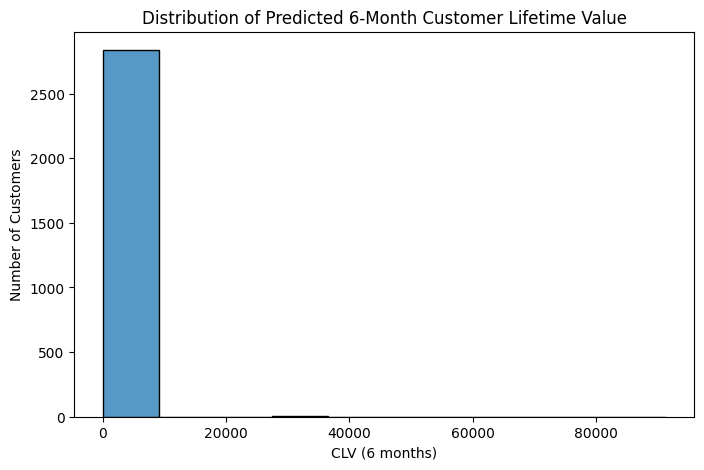

In [86]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['CLV_6m'], bins=10)
plt.title("Distribution of Predicted 6-Month Customer Lifetime Value")
plt.xlabel("CLV (6 months)")
plt.ylabel("Number of Customers")
plt.show()

CLV distribution is highly right-skewed, indicating that a small proportion of customers accounts for disproportionately high predicted future revenue, consistent with typical Pareto-like customer value structure.

**Recency vs Frequency (CLV Colored)**

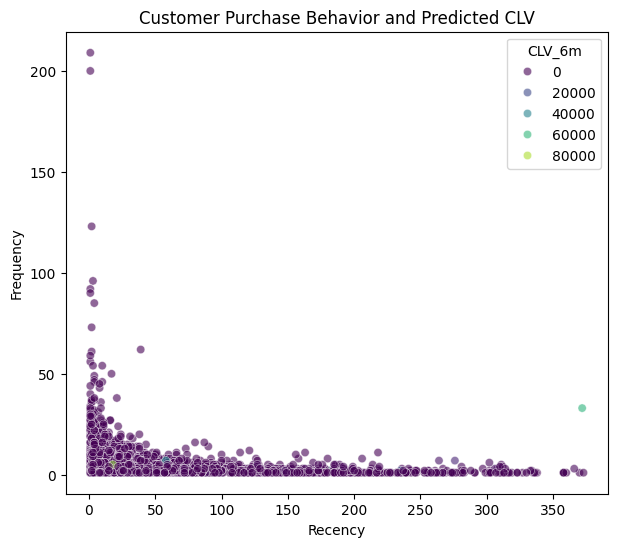

In [87]:
plt.figure(figsize=(7,6))
sns.scatterplot(
    x='recency',
    y='frequency',
    hue='CLV_6m',
    palette='viridis',
    data=rfm,
    alpha=0.6
)
plt.title("Customer Purchase Behavior and Predicted CLV")
plt.xlabel("Recency")
plt.ylabel("Frequency")
plt.show()

Customers with higher recency (more recent activity) exhibit substantially higher predicted CLV regardless of historical purchase frequency, demonstrating that recent engagement is the dominant driver of future value in probabilistic CLV modeling.

**Segment Revenue Contribution**

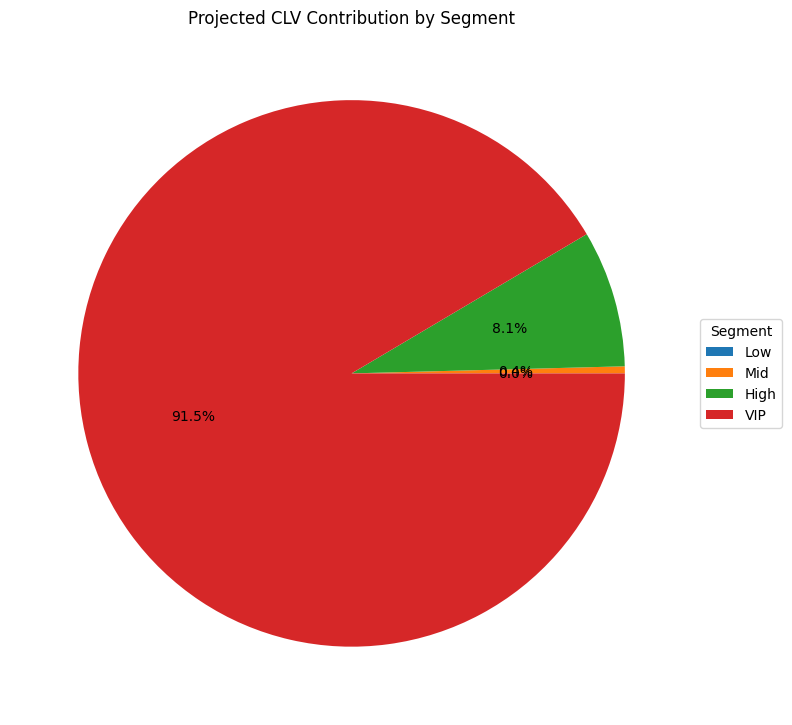

In [100]:
plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    segment_rev,
    autopct="%1.1f%%"
)

plt.legend(
    wedges,
    segment_rev.index,
    title="Segment",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Projected CLV Contribution by Segment")
plt.tight_layout()
plt.savefig("../images/CLVsegment.png", dpi=300, bbox_inches="tight")
plt.show()

A disproportionate share of projected future revenue is concentrated in the VIP segment, highlighting the presence of a high-value customer core and supporting value-based marketing prioritization.

**Segment Behavior Profile**

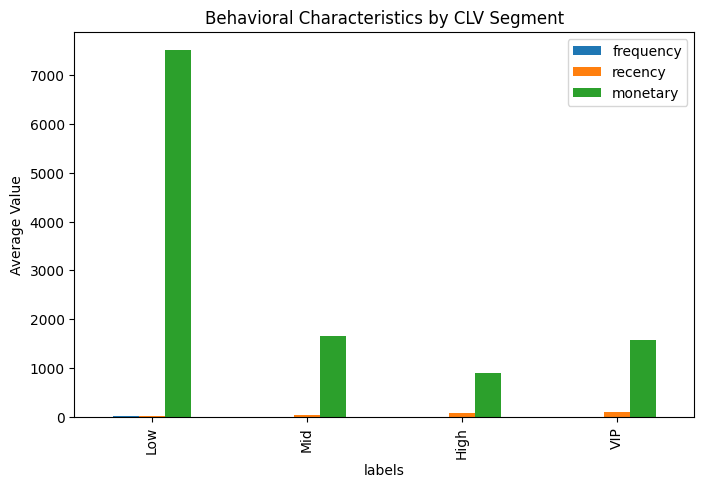

In [89]:
segment_profile[['frequency','recency','monetary']].plot(
    kind='bar',
    figsize=(8,5)
)
plt.title("Behavioral Characteristics by CLV Segment")
plt.ylabel("Average Value")
plt.show()

**Final Visualization Summary**

Visualization of predicted customer lifetime value reveals a strongly skewed distribution with substantial heterogeneity across segments. VIP customers contribute a disproportionately large share of projected future revenue and exhibit the highest recent engagement. Scatter analysis confirms that recency and survival probability are the primary drivers of CLV, outweighing historical purchase frequency. These patterns validate the probabilistic CLV model and support value-based customer segmentation and marketing prioritization.

## 9. Conclusion

This analysis demonstrates how transactional data can be transformed into forward-looking customer lifetime value intelligence using probabilistic modeling. The BG/NBD and Gamma-Gamma framework captures customer purchase dynamics, survival likelihood, and expected future revenue at the individual level.

Results reveal pronounced heterogeneity in customer value and emphasize the critical role of recent engagement in predicting future purchasing behavior. CLV segmentation identifies a high-value customer core driving projected revenue and supports targeted marketing strategies for retention, growth, and reactivation.

Overall, the project illustrates the application of probabilistic data science methods to real-world marketing analytics, enabling businesses to prioritize customers based on predicted lifetime value and optimize resource allocation.
